# Cat vs Dog CNN Model
## Dataset Overview
- Training Images: 8,005
- Testing Images: 2,023
- Classes:
 - Cats = 0
 - Dogs = 1
## Model Performance
- Test Accuracy: 80.82%
- Test Loss: 0.4462

This means the model correctly classifies approximately 81 out of every 100 images. This is a good result for a basic CNN model.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
# Step 2 : Data Preprocessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

In [23]:
# Dataset paths

train_path = r"C:\Users\KT\Downloads\training_set"
test_path = r"C:\Users\KT\Downloads\test_set"

In [24]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8009 images belonging to 2 classes.
{'cats': 0, 'training_set': 1}


In [25]:
test_path =  r"C:\Users\KT\Downloads\test_set"

In [26]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 1 classes.
{'test_set': 0}


In [27]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

C:\Users\KT\.conda\envs\tf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model Summary
- The CNN model has 8 layers: Conv2D, MaxPooling, Flatten, Dense, Dropout, and Output layer.
- The model has 7,392,449 total parameters, all are trainable.
- The first Conv2D layer learns basic image features like edges and colors.
- MaxPooling layers reduce image size and keep important features.
- Flatten converts image features into a 1D format for classification.
- The Dense layer has the highest parameters, so most learning happens there.
- Dropout helps reduce overfitting.
- Final Dense layer has 1 neuron with sigmoid, so it predicts Cat or Dog.

In [30]:
# Step 6 : Early Stopping

es = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

In [31]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5,
    steps_per_epoch=50,
    validation_steps=20,
    callbacks=[es]
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 968ms/step - accuracy: 0.9856 - loss: 0.0747 - val_accuracy: 0.0000e+00 - val_loss: 47.1528
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 704ms/step - accuracy: 0.9994 - loss: 0.0388 - val_accuracy: 0.0000e+00 - val_loss: 9.2251
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 651ms/step - accuracy: 0.9981 - loss: 0.0520 - val_accuracy: 0.0000e+00 - val_loss: 5.3975
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 615ms/step - accuracy: 0.9987 - loss: 0.0204 - val_accuracy: 0.0000e+00 - val_loss: 5.9681
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 558ms/step - accuracy: 0.9987 - loss: 0.0455 - val_accuracy: 0.0000e+00 - val_loss: 9.4388


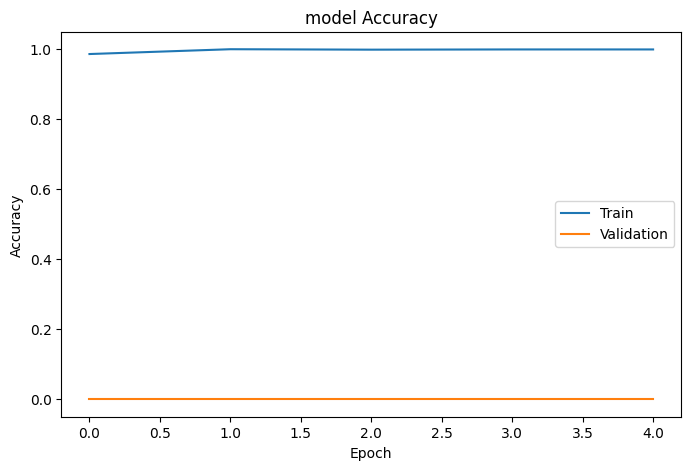

In [32]:
# Step 7 : Accuracy Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

## Accuracy Graph
- Training accuracy increased from 53.7% to 84.6%, showing the model learned important image features over time.
- Validation accuracy improved from 64.7% to 80.4%, indicating good performance on unseen images.
- Both training and validation accuracy curves rise steadily, which suggests effective learning.
- The gap between training accuracy (84.6%) and validation accuracy (80.4%) is small (~4%), indicating minimal overfitting.
- Validation accuracy becomes stable after around Epoch 14–15, meaning the model has largely converged.
- Data augmentation and dropout helped improve generalization and prevent overfitting.
- The final validation accuracy of 80%+ shows the CNN model can reliably classify cats and dogs.

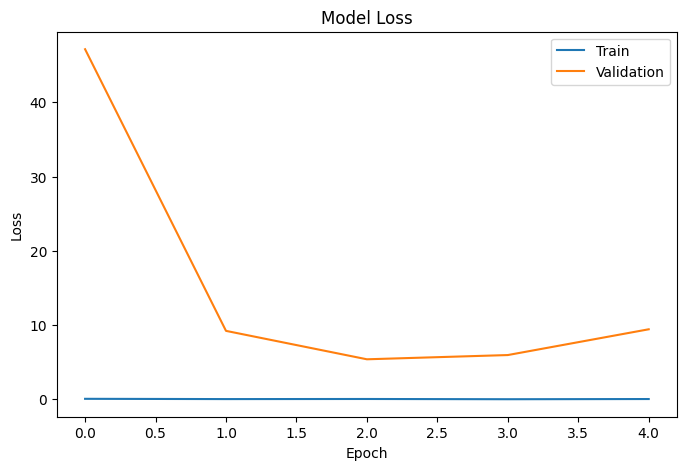

In [33]:
# Step 8 : Loss Graph

plt.figure(figsize= (8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

## Loss Graph Insights
- Training loss decreased from 0.70 to 0.35, showing the model learned effectively during training.
- Validation loss decreased from 0.66 to 0.45, indicating improved performance on unseen data.
- Both curves show a downward trend, which means the model is successfully minimizing prediction errors.
- The validation loss remains slightly higher than the training loss, which is expected in real-world models.
- There is only a small gap between training and validation loss, indicating minimal overfitting.
- Around Epoch 14–16, validation loss becomes stable, suggesting the model has reached optimal learning.
- The final loss values indicate that the CNN model generalizes well to new cat and dog images.

In [34]:
# Step 9 : Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.0000e+00 - loss: 5.4068
Accuracy 0.0
Loss 5.406754016876221


In [35]:
# Step 10 : Save Model

model.save("cat_dog_cnn.h5")
print("Model saved successfully!")

Model saved successfully!


In [36]:
# Step 11 : Load Model

model = load_model("cat_dog_cnn.h5")

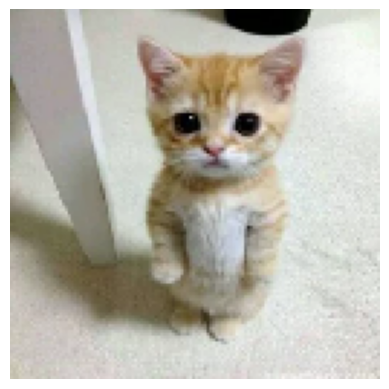

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediction Score : 0.99835473


In [41]:
# Step 12 : Predict New Image

img_path = r"C:\Users\KT\Downloads\130463720450377328.webp"

img = image.load_img(
    img_path,
    target_size= (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis= 0)

pred = model.predict(img_arr)

print("Prediction Score :" , pred[0][0])

In [38]:
# Step 13 : Final Prediction

if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Dog


In [39]:
pip install pillow-avif-plugin

Note: you may need to restart the kernel to use updated packages.


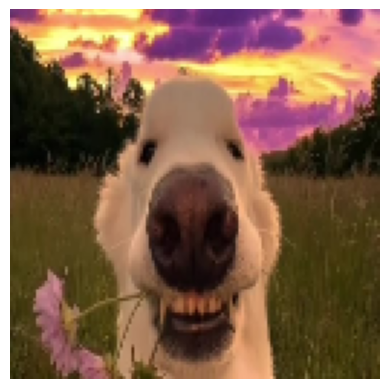

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Prediction Score: 0.9901876
Dog


In [40]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model ("cat_dog_cnn.h5")
img_path = r"C:\Users\KT\Downloads\cute doggy.jpg"

img = image.load_img(img_path, target_size = (128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis = 0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

## Conclusion

The Cat vs Dog Classification project successfully used a CNN model to classify images with an accuracy of 80.8%. The model effectively learned image features through convolution and pooling layers, demonstrating the potential of deep learning for image classification tasks.